In [133]:
#Librerie
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
import altair as alt

In [134]:
filterwarnings("ignore")

In [135]:
#Definizione di funzioni per calcolare sse, bss e le performance di clusteirng
def get_sse(X, labels):
    sse = 0
    for l in np.unique(labels):
        c = np.mean(X[labels == l], axis=0)
        sse += np.sum(cdist(np.expand_dims(c, axis=0), X[labels == l]) ** 2)
    return sse


def get_bss(X, labels):
    cluster_centers = list()
    for l in np.unique(labels):
        c = np.mean(X[labels == l], axis=0)
        cluster_centers.append(c)
    cluster_centers = np.array(cluster_centers)
    _, sizes = np.unique(labels, return_counts=True)
    m = np.mean(X, axis=0)
    bss = np.sum(sizes * cdist(np.expand_dims(m, axis=0), cluster_centers) ** 2)
    return bss


def eval_clustering(X, labels):
    sse = get_sse(X[labels != -1], labels[labels != -1])
    bss = get_bss(X[labels != -1], labels[labels != -1])
    silh = silhouette_score(X[labels != -1], labels[labels != -1])
    return sse, bss, silh

In [136]:
#Dataset necessari
df_event_profile = pd.read_csv("Event_profile_static.csv")
df_event_year = pd.read_csv("Event_features_by_year.csv")

In [137]:
df_event_profile

,sport,event,is_team_event,n_nations_mean,n_nations_max,n_athletes_mean,gold_per_athlete,n_nations_with_gold,total_per_athlete,n_nations_with_medal,n_editions,hhi_gold,hhi_total
0,3x3 Basketball,"3x3 Basketball, Men",True,8.000000,8,8.000000,0.250000,1.0,0.208333,3.000000,1,1.000000,0.333333
1,3x3 Basketball,"3x3 Basketball, Women",True,8.000000,8,8.000000,0.250000,1.0,0.166667,3.000000,1,1.000000,0.333333
2,Archery,"Individual, Men",False,30.384615,37,58.538462,0.214103,1.0,0.219658,2.923077,13,0.207101,0.109796
3,Archery,"Individual, Women",False,27.769231,38,52.769231,0.179487,1.0,0.317308,2.076923,13,0.514793,0.270217
4,Archery,"Team, Men",True,14.444444,21,14.444444,0.175926,1.0,0.182099,3.000000,9,0.481481,0.163237
...,...,...,...,...,...,...,...,...,...,...,...,...,...
452,Wushu,"Sanshou (≤60 kilograms), Women",False,7.000000,7,7.000000,NaN,0.0,NaN,0.000000,1,NaN,NaN
453,Wushu,"Sanshou (≤70 kilograms), Men",False,7.000000,7,7.000000,NaN,0.0,NaN,0.000000,1,NaN,NaN
454,Wushu,"Sanshou (≤85 kilograms), Men",False,8.000000,8,8.000000,NaN,0.0,NaN,0.000000,1,NaN,NaN
455,Wushu,"Taijiquan & Taijijuan, Men",False,8.000000,8,8.000000,NaN,0.0,NaN,0.000000,1,NaN,NaN


In [138]:
df_event_profile.shape

(457, 13)

In [139]:
# Per l'analisi di clustering mantengo solo gli eventi che sono stati presenti in almeno 5 edizioni olimpiche
df_event_profile = df_event_profile[df_event_profile['n_editions'] >= 5]

In [140]:
df_event_profile.shape

(317, 13)

In [141]:
df_event_profile

,sport,event,is_team_event,n_nations_mean,n_nations_max,n_athletes_mean,gold_per_athlete,n_nations_with_gold,total_per_athlete,n_nations_with_medal,n_editions,hhi_gold,hhi_total
2,Archery,"Individual, Men",False,30.384615,37,58.538462,0.214103,1.000000,0.219658,2.923077,13,0.207101,0.109796
3,Archery,"Individual, Women",False,27.769231,38,52.769231,0.179487,1.000000,0.317308,2.076923,13,0.514793,0.270217
4,Archery,"Team, Men",True,14.444444,21,14.444444,0.175926,1.000000,0.182099,3.000000,9,0.481481,0.163237
6,Archery,"Team, Women",True,13.222222,16,13.222222,0.166667,1.000000,0.196914,3.000000,9,1.000000,0.163237
7,Artistic Gymnastics,"Balance Beam, Women",False,28.333333,47,86.600000,0.095873,1.000000,0.124211,2.200000,15,0.218750,0.180529
...,...,...,...,...,...,...,...,...,...,...,...,...,...
437,Wrestling,"Middleweight, Greco-Roman, Men",False,18.466667,21,18.466667,0.099287,1.000000,0.125407,3.266667,15,0.137778,0.050396
438,Wrestling,"Super-Heavyweight, Freestyle, Men",False,15.769231,20,15.769231,0.065252,1.076923,0.079456,3.307692,13,0.204082,0.080584
439,Wrestling,"Super-Heavyweight, Greco-Roman, Men",False,15.846154,20,15.846154,0.063130,1.000000,0.111623,3.307692,13,0.242604,0.068686
440,Wrestling,"Welterweight, Freestyle, Men",False,20.533333,25,20.533333,0.073890,1.000000,0.094825,3.266667,15,0.155556,0.061224


In [142]:
df_event_profile.columns

Index(['sport', 'event', 'is_team_event', 'n_nations_mean', 'n_nations_max',
       'n_athletes_mean', 'gold_per_athlete', 'n_nations_with_gold',
       'total_per_athlete', 'n_nations_with_medal', 'n_editions', 'hhi_gold',
       'hhi_total'],
      dtype='object')

In [143]:
#Calcolo la correlazione tra le variabili numeriche per scegliere quelle da usare nel clustering
num_features = ['is_team_event', 'n_nations_mean', 'n_nations_max', 'n_athletes_mean', 'gold_per_athlete', 'n_nations_with_gold', 'total_per_athlete', 'n_nations_with_medal', 'n_editions', 'hhi_gold', 'hhi_total']

corr = df_event_profile[num_features].corr()

corr

,is_team_event,n_nations_mean,n_nations_max,n_athletes_mean,gold_per_athlete,n_nations_with_gold,total_per_athlete,n_nations_with_medal,n_editions,hhi_gold,hhi_total
is_team_event,1.000000,-0.524424,-0.505226,-0.477170,-0.182969,-0.026974,-0.216533,0.070734,-0.083346,0.276668,0.088420
n_nations_mean,-0.524424,1.000000,0.954969,0.779480,-0.137831,0.245105,-0.090993,-0.015570,0.228798,-0.180483,0.081046
n_nations_max,-0.505226,0.954969,1.000000,0.773181,-0.200378,0.240925,-0.161548,-0.072470,0.344664,-0.213291,0.069351
n_athletes_mean,-0.477170,0.779480,0.773181,1.000000,-0.046351,0.231884,0.004352,-0.251770,0.285354,-0.181816,0.131204
gold_per_athlete,-0.182969,-0.137831,-0.200378,-0.046351,1.000000,-0.314920,0.922500,0.040240,-0.305990,-0.062022,-0.111140
n_nations_with_gold,-0.026974,0.245105,0.240925,0.231884,-0.314920,1.000000,-0.298886,0.448953,0.217352,-0.100027,-0.102145
total_per_athlete,-0.216533,-0.090993,-0.161548,0.004352,0.922500,-0.298886,1.000000,-0.010225,-0.293877,0.024663,-0.039133
n_nations_with_medal,0.070734,-0.015570,-0.072470,-0.251770,0.040240,0.448953,-0.010225,1.000000,-0.003680,-0.085979,-0.597175
n_editions,-0.083346,0.228798,0.344664,0.285354,-0.305990,0.217352,-0.293877,-0.003680,1.000000,-0.353939,-0.198942
hhi_gold,0.276668,-0.180483,-0.213291,-0.181816,-0.062022,-0.100027,0.024663,-0.085979,-0.353939,1.000000,0.563076


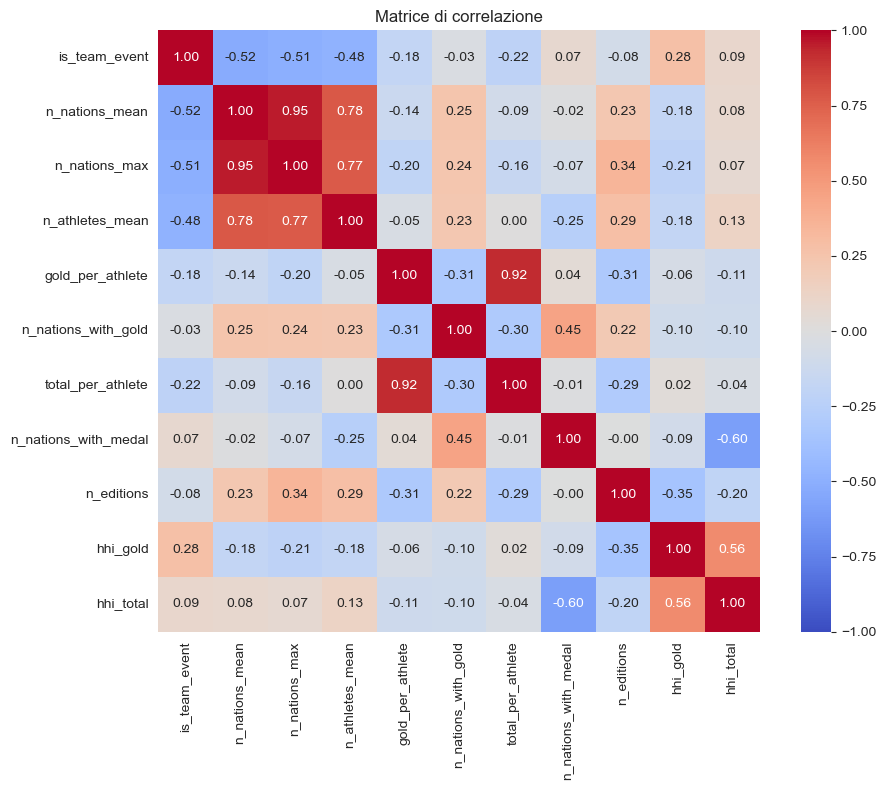

In [144]:
#Plotto la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

In [145]:
# In base alle correlazioni osservate, mantengo un sottoinsieme di 5 features per il clustering. Nonostante n_editions non sia correlata con nessun'altra feature, non la inserisco nel clustering perchè mi serviva soltanto per filtrare gli sport da mantenere in fase di clustering
feat_for_clust = ['is_team_event', 'n_nations_mean', 'gold_per_athlete', 'hhi_gold', 'n_nations_with_gold']

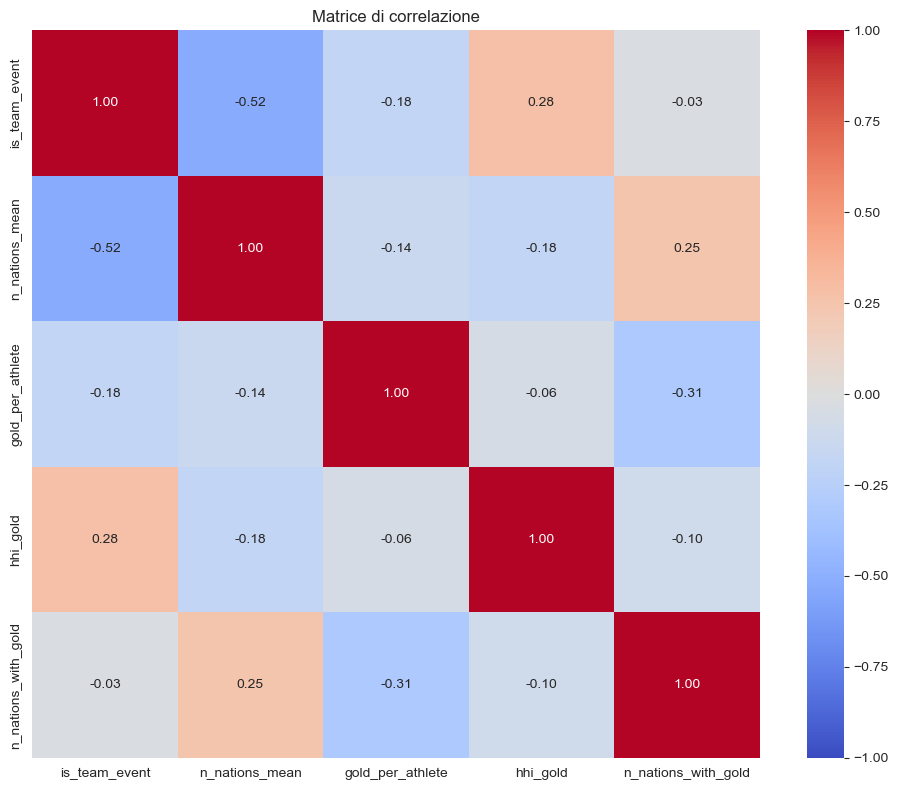

In [146]:
# Verifico nuovamente le correlazioni
corr2 = df_event_profile[feat_for_clust].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr2, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

In [147]:
print(df_event_profile.isna().sum())

sport                   0
event                   0
is_team_event           0
n_nations_mean          0
n_nations_max           0
n_athletes_mean         0
gold_per_athlete        2
n_nations_with_gold     0
total_per_athlete       2
n_nations_with_medal    0
n_editions              0
hhi_gold                2
hhi_total               2
dtype: int64


In [148]:
df_event_profile.shape

(317, 13)

In [149]:
#Elimino le due righe con i valori NaN
events_to_drop = [
    ('Athletics', '1,500 metres Wheelchair, Men'),
    ('Athletics', '800 metres Wheelchair, Women')
]

mask = df_event_profile.apply(
    lambda row: (row['sport'], row['event']) in events_to_drop, axis=1
)

df_event_profile = df_event_profile[~mask]

In [150]:
df_event_profile.shape

(315, 13)

In [151]:
#Standardizzo le features per il clustering
X = df_event_profile[feat_for_clust]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [152]:
# valuto il clustering con diversi k per scegliere il migliore
kmin = 2
kmax = 20

krange = np.arange(kmin, kmax, 1)

results = {
    "sse": list(),
    "bss": list(),
    "silh": list()
}

for k in krange:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    sse, bss, silh = eval_clustering(X_scaled, labels)
    results["sse"].append(sse)
    results["bss"].append(bss)
    results["silh"].append(silh)

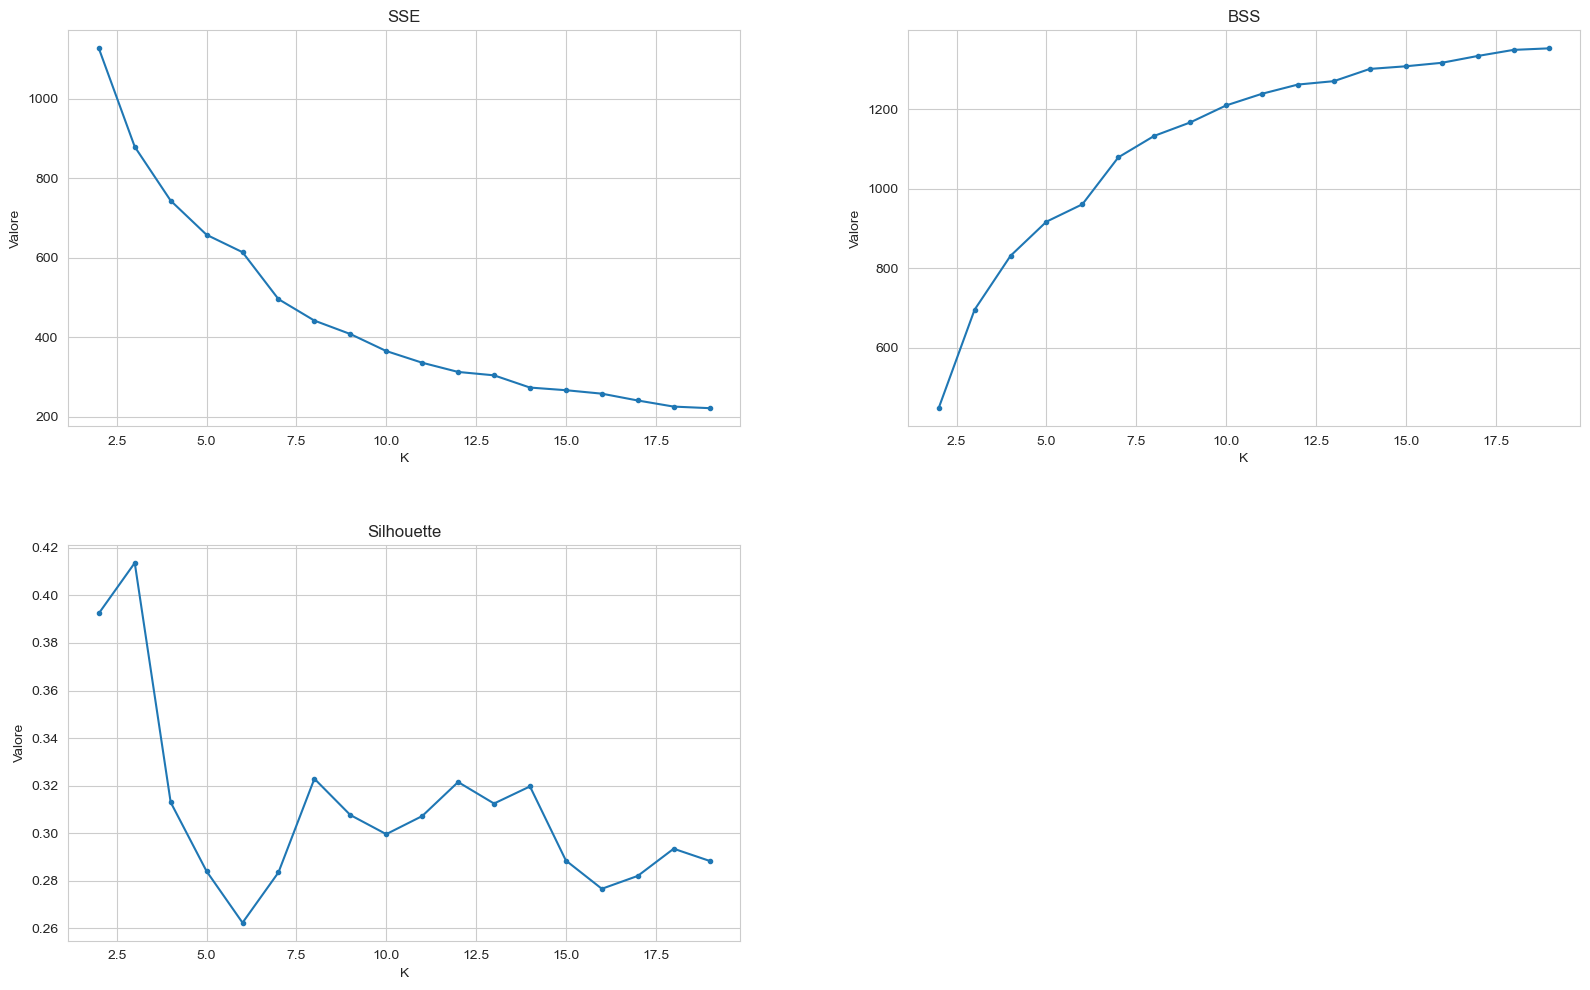

In [153]:
#plotto i risultati
metrics = ["sse", "bss", "silh"]
titles = ["SSE", "BSS", "Silhouette"]
nrows = 2
ncols = 2

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 10))
axes = axes.flatten()

for i, metrica in enumerate(metrics):
    ax = axes[i]
    ax.plot(krange, results[metrica], marker=".")
    ax.set_title(titles[i])
    ax.set_xlabel("K")
    ax.set_ylabel("Valore")
    ax.grid(True)

axes[3].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.25)
plt.show()

In [154]:
# Scelgo k = 4 perchè su questo valore individuo il gomito a scendere nel grafico della SSE, il gomito a salire in quello della BSS e il picco in quello della silhouette
n_clust_4 = KMeans(n_clusters=4,  random_state=42)
n_clust_4.fit(X_scaled)
df_event_profile['cluster_k4'] = n_clust_4.labels_

In [155]:
#Numero di istanze in ogni cluster
labels, sizes = np.unique(n_clust_4.labels_, return_counts=True)
for l, s in zip(labels, sizes):
    print("Cluster %s: %d (%.2f)" % (l, s, s/len(X)))

Cluster 0: 162 (0.51)
Cluster 1: 58 (0.18)
Cluster 2: 82 (0.26)
Cluster 3: 13 (0.04)


In [156]:
#Rendo uniformi i colori per i cluster nei vari grafici
cluster_colors = {
    'Cluster 0': '#4c78a8',
    'Cluster 1': '#f58518',
    'Cluster 2': '#e45756',
    'Cluster 3': '#b279a2',
}

color_scale = alt.Scale(
    domain=list(cluster_colors.keys()),
    range=list(cluster_colors.values())
)

In [157]:
# Visualizzo i centroidi dei cluster tramite coordinate parallele
centroids = pd.DataFrame(
    n_clust_4.cluster_centers_,
    columns=feat_for_clust
)
centroids['cluster'] = [f'Cluster {i}' for i in range(len(centroids))]

centroids_long = centroids.melt(
    id_vars='cluster',
    value_vars=feat_for_clust,
    var_name='feature',
    value_name='valore'
)

alt.Chart(centroids_long).mark_line(point=True).encode(
    x=alt.X('feature:N', sort=feat_for_clust, title=None, axis=alt.Axis(labelAngle=0)),
    y=alt.Y('valore:Q', title='Valori'),
    color=alt.Color('cluster:N', title='Cluster', scale=color_scale),
    tooltip=['cluster', 'feature', 'valore']
).properties(
    width=500,
    height=300,
    title='Coordinate parallele — centroidi cluster'
).interactive()

alt.Chart(...)

In [158]:
#PCA per visualizzare i cluster
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns =['PC1', 'PC2'])
df_pca['cluster'] = ['Cluster ' + str(c) for c in df_event_profile['cluster_k4'].values]
df_pca['event'] = df_event_profile['event'].values

alt.Chart(df_pca).mark_circle(size=80, opacity=0.6).encode(
    x = alt.X('PC1:Q', title ='Prima componente principale'),
    y = alt.Y('PC2:Q', title='Seconda componente principale'),
    color=alt.Color('cluster:N', title='Cluster', scale=color_scale),
    tooltip=['event', 'cluster']
).properties(
    width=500,
    height=400,
    title='PCA - Clustering eventi sportivi'
).interactive()

alt.Chart(...)

In [159]:
#Visualizzo la composizione dei cluster, quindi quali sport appartengono ad ogni cluster
for k in sorted(df_event_profile['cluster_k4'].unique()):
    sports = df_event_profile[df_event_profile['cluster_k4'] == k]['event'].tolist()
    print(f"\nCluster {k}:")
    print(sports)


Cluster 0:
['Individual, Women', 'Balance Beam, Women', 'Floor Exercise, Women', 'Horizontal Bar, Men', 'Horse Vault, Women', 'Individual All-Around, Men', 'Individual All-Around, Women', 'Parallel Bars, Men', 'Pommelled Horse, Men', 'Rings, Men', 'Uneven Bars, Women', '1,500 metres, Men', '1,500 metres, Women', '10,000 metres, Men', '10,000 metres, Women', '100 metres Hurdles, Women', '100 metres, Men', '100 metres, Women', '110 metres Hurdles, Men', '20 kilometres Race Walk, Men', '20 kilometres Race Walk, Women', '200 metres, Men', '200 metres, Women', '3,000 metres Steeplechase, Men', '400 metres Hurdles, Men', '400 metres Hurdles, Women', '400 metres, Men', '400 metres, Women', '5,000 metres, Men', '5,000 metres, Women', '50 kilometres Race Walk, Men', '800 metres, Men', '800 metres, Women', 'Decathlon, Men', 'Discus Throw, Men', 'Discus Throw, Women', 'Hammer Throw, Men', 'Hammer Throw, Women', 'Heptathlon, Women', 'High Jump, Men', 'High Jump, Women', 'Javelin Throw, Men', 'Jav

## INTERPRETAZIONE CLUSTER

- Cluster 0, il cluster degli "eventi individuali standard": la percentuale di eventi di squadra è bassa, il numero di nazioni che gareggiano è medio, il rapporto oro/atleti è medio-basso, la concentrazione degli ori (HHI) è nella media-bassa, e il numero di nazioni con ori è discreto. È una grande lista di eventi variegata senza caratteristiche estreme, il calderone degli eventi individuali generici.
- Cluster 1, il cluster degli "eventi individuali meno diffusi": anche qui la percentuale di eventi di squadra è bassa e ci sono meno nazioni partecipenti rispetto al cluster 0; il numero di ori in base agli atleti è alto, mentre l'hhi è basso (sport democratici in cui generalmente vincono paesi per cui gareggiano pochi atleti), anche il numero di nazioni con ori è basso.
- Cluster 2, il cluster degli "eventi di squadra": ha la percentuale di eventi di squadra più alta rispetto a tutti gli altri cluster; ci sono pochissime nazioni che gareggiano; il rapporto tra ori e numero di atleti è basso perchè si conta un unico oro per tutta la squadra, mentre l'hhi è alto (ci sono quindi poche nazioni dominanti), cosa che trova riscontro nel basso valore del numero di nazioni con ori.
- Cluster 3, il cluster "degli eventi dominati": pochi eventi di squadra, basso numero di nazioni patecipanti, l'oro oer atleti è il più alto rispetto a tutti gli altri cluster (quindi ci sono pochi atleti che vincono l'oro), la concentrazioni degli ori è medio-alta e ci sono davvero poche nazioni che hanno vinto un oro in questi eventi.

## Analisi temporale

In [160]:
#Unisco la colonna dei cluster al dataset event_year
df_event_year = df_event_year.merge(
    df_event_profile[['sport', 'event', 'cluster_k4']],
    on=['sport', 'event'],
    how='left'
)

df_event_year = df_event_year.dropna(subset=['cluster_k4'])
df_event_year['cluster_k4'] = df_event_year['cluster_k4'].astype(int)

In [161]:
df_event_year

,sport,event,year,n_nations,n_athletes,is_team_event,gold_per_athlete,n_nations_with_gold,total_per_athlete,n_nations_with_medal,cluster_k4
2,Archery,"Individual, Men",1972,23,54,False,0.166667,1,0.233333,3,1
3,Archery,"Individual, Men",1976,23,37,False,0.250000,1,0.250000,3,1
4,Archery,"Individual, Men",1980,23,36,False,0.250000,1,0.277778,3,1
5,Archery,"Individual, Men",1984,28,56,False,0.166667,1,0.266667,2,1
6,Archery,"Individual, Men",1988,31,79,False,0.166667,1,0.166667,3,1
...,...,...,...,...,...,...,...,...,...,...,...
3857,Wrestling,"Welterweight, Greco-Roman, Men",2004,20,20,False,0.142857,1,0.103175,3,0
3858,Wrestling,"Welterweight, Greco-Roman, Men",2008,20,20,False,0.111111,1,0.121181,4,0
3859,Wrestling,"Welterweight, Greco-Roman, Men",2012,19,19,False,0.111111,1,0.124389,4,0
3860,Wrestling,"Welterweight, Greco-Roman, Men",2016,18,18,False,0.333333,1,0.155168,4,0


In [162]:
trend_k4= df_event_year.groupby(['cluster_k4', 'year'])[['n_nations', 'gold_per_athlete', 'n_athletes']].mean().reset_index()

In [163]:
trend_k4['cluster_k4'] = trend_k4['cluster_k4'].apply(lambda x: f'Cluster {x}')

In [164]:
#Plotto i grafici sull'andamento delle seguenti features nel corso del tempo: nazioni partecipanti, concentrazione ori, perdia ori per atleta, atleti per evento
metrics = {
    'n_nations': 'Nazioni partecipanti',
    'gold_per_athlete': 'Efficienza ori per atleta',
    'n_athletes': 'Atleti per evento'
}

charts = []
for col, title in metrics.items():
    chart = alt.Chart(trend_k4).mark_line(point=True).encode(
        x=alt.X('year:O', title='Anno'),
        y=alt.Y(f'{col}:Q', title=title),
        color=alt.Color('cluster_k4:N', title='Cluster', scale=color_scale),
        tooltip=['cluster_k4', 'year', alt.Tooltip(f'{col}:Q', format='.2f')]
    ).properties(
        width=350,
        height=250,
        title=title
    )
    charts.append(chart)

alt.hconcat(*charts).properties(
    title='Evoluzione temporale cluster k=4'
)


alt.HConcatChart(...)

## Interpretazione

- Cluster 0, eventi individuali standard: il cluster con il numero più alto di nazioni partecipanti nel corso del tempo (presenta un calo nel 1980 a causa del boicottaggio di Mosca). C'è bassa e stabile efficienza di ori per atleta e c'è il numero più alto di atleti per evento (solito calo nel 1980)
- Cluster 1, eventi individuali meno diffusi: il numero di nazioni partecipanti tende a crescere nel corso del tempo, è il secondo cluster con maggior numero di nazioni partecipanti. L'efficienza oro per atleta è alta e c'è un numero abbastanza alto di atleti per evento nel corso del tempo (il secondo più numeroso dopo il cluster 0).
- Cluster 2, eventi di squadra: basso e stabile numero di nazioni partecipanti, bassa efficienza di oro per atleta (1 oro per la squadra e non per ogni componente), basso numero atleti per evento.
- Cluster 3, eventi dominati: presenta il più basso e instabile numero di nazioni partecipanti nel corso del tempo, con un crollo quasi a zero nel 1980 a causa del boicottaggio di Mosca — l'effetto più drammatico tra tutti i cluster, segno che questi eventi dipendevano da pochissime nazioni specifiche. L'efficienza di ori per atleta è alta e instabile, il numero di atleti per evento è basso e instabile.